In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('../data/kyle_schwarber_full_data.csv')
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'homerun'])
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]
data.head(15)
data.dtypes

data['pitch_name'].head()

0    Split-Finger
1       Curveball
2    Split-Finger
3    Split-Finger
4    Split-Finger
Name: pitch_name, dtype: object

In [3]:
# Summary Statistics for Numeric Columns:

# Effective Speed:
print('Effective Speed:')
print(f'Sample Size: {data['effective_speed'].count()}')
print(f'Mean: {data['effective_speed'].mean()}')
print(f'Standard Deviation: {data['effective_speed'].std()}')
print(' ')

# Release Spin Rate:
print('Release Spin Rate:')
print(f'Sample Size: {data['release_spin_rate'].count()}')
print(f'Mean: {data['release_spin_rate'].mean()}')
print(f'Standard Deviation: {data['release_spin_rate'].std()}')
print(' ')

Effective Speed:
Sample Size: 13797
Mean: 88.95269261433644
Standard Deviation: 6.333648769202175
 
Release Spin Rate:
Sample Size: 13787
Mean: 2239.1792268078625
Standard Deviation: 367.9563654174144
 


In [4]:
# Summary Statistic for Categorical Columns:

# Zone
print('Zone:')
print(f'Sample Size: {data['zone'].count()}')
print(f'Category Counts: {data['zone'].value_counts()}')
print(' ')

# Pitcher Throws:
print('Pitcher Throws:')
print(f'Sample Size: {data['p_throws'].count()}')
print(f'Category Counts: {data['p_throws'].value_counts()}')
print(' ')

# Pitch Count:
print('Pitch Count:')
print(f'Sample Size: {data['pitch_count'].count()}')
print(f'Category Counts: {data['pitch_count'].value_counts()}')
print(' ')

# Pitch Number:
print('Pitch Number:')
print(f'Sample Size: {data['pitch_number'].count()}')
print(f'Category Counts: {data['pitch_number'].value_counts()}')
print(' ')

# Pitch Name:
print('Pitch Name:')
print(f'Sample Size: {data['pitch_name'].count()}')
print(f'Category Counts: {data['pitch_name'].value_counts()}')
print(' ')

Zone:
Sample Size: 13846
Category Counts: zone
13.0    2741
11.0    1803
14.0    1798
4.0     1007
5.0      947
12.0     901
7.0      864
8.0      839
2.0      675
1.0      669
6.0      638
9.0      549
3.0      415
Name: count, dtype: int64
 
Pitcher Throws:
Sample Size: 13920
Category Counts: p_throws
R    9005
L    4915
Name: count, dtype: int64
 
Pitch Count:
Sample Size: 13920
Category Counts: pitch_count
0-0    3287
0-1    1547
1-1    1454
1-0    1437
2-2    1261
1-2    1243
3-2     904
2-1     904
0-2     688
2-0     567
3-1     411
3-0     217
Name: count, dtype: int64
 
Pitch Number:
Sample Size: 13920
Category Counts: pitch_number
1     3287
2     2984
3     2630
4     2177
5     1506
6      863
7      317
8      101
9       36
10      13
11       4
12       1
13       1
Name: count, dtype: int64
 
Pitch Name:
Sample Size: 13843
Category Counts: pitch_name
4-Seam Fastball    4250
Slider             2263
Sinker             2019
Changeup           1535
Cutter             1204
C

In [5]:
cols = ['effective_speed', 'release_spin_rate']
subset = data[cols]
corr_matrix = subset.corr()
print(corr_matrix)

                   effective_speed  release_spin_rate
effective_speed           1.000000          -0.022931
release_spin_rate        -0.022931           1.000000


The correlation matrix for the two numerical variables showed that there is essentially no linear relationship between effective_speed and release_spin_rate. These variables seem to capture different aspects of a pitch and both give unique information to the model. Effective pitch speed has a mean of about 89 mph with a relatively low variablility while release spin rate has a mean of 2239 rpm with a large standard deviation.

The categorical variables are interesting as they show that pitches from right handed pitchers are much more frequent and that certain zones are targeted much more frequently than others. In this context it seems like the categorical predictors could have more of an influence on predicting outcomes than the raw numerical data. It is interesting that a pitcher many times is able to choose something different for each of the predictors we are using. A certain type of pitch and hand grip could make any combo of spin and speed. They are able to choose which zone to aim for, and very rarely, some pitchers are able to pitch with both hands.

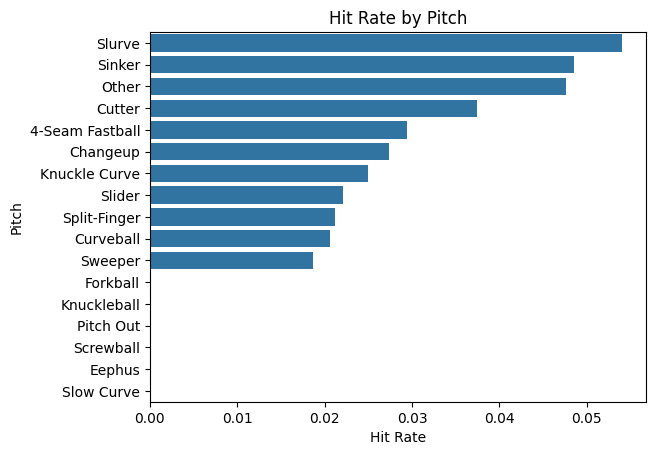

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

pitch_hit_rate = (
    data.groupby('pitch_name')['hits']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=pitch_hit_rate, x='hits', y='pitch_name')
plt.title('Hit Rate by Pitch')
plt.xlabel('Hit Rate')
plt.ylabel('Pitch')
plt.show()

Since pitch type is what we were assuming would be one of the most important predictors, we graphed hit rate by pitch type. We were surprised to see that 4-Seam Fastball wasn't in the top three since almost half of all pitches league wide are fastballs. From this graph, we were able to see that in general, it looks like Schwarber has the hardest time with the slowest pitch types.

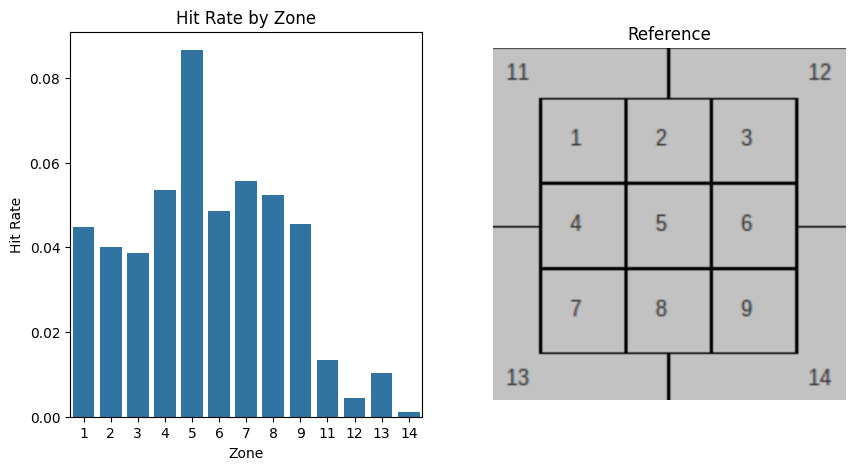

In [15]:
img = mpimg.imread("./data/strike_zones.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

zone_hit_rate = (
    data.groupby('zone', observed=False)['hits']
    .mean()
    .reset_index()
    .sort_values('zone')
)

zone_hit_rate['zone'] = zone_hit_rate['zone'].astype(int)

sns.barplot(data=zone_hit_rate, x='zone', y='hits', ax=axes[0])
axes[0].set_title('Hit Rate by Zone')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Hit Rate')

axes[1].imshow(img)
axes[1].axis('off')
axes[1].set_title("Reference")

plt.show()



Zone placement will also be a very important predictor. Generally pitchers try to aim for the outside edges of the strike zone in order to make a batter choke up on the bat or overextend themselves. When the count is high or a pitcher is tired, however, it is more common to see pitches more towards the center. Based on our data, these are the pitches that Schwarber tends to hit most often. The rest of the strike zone seems to be fairly equal hit rate, with the areas just outside the strike zone on the far side of the plate being the pitches he hits the least.

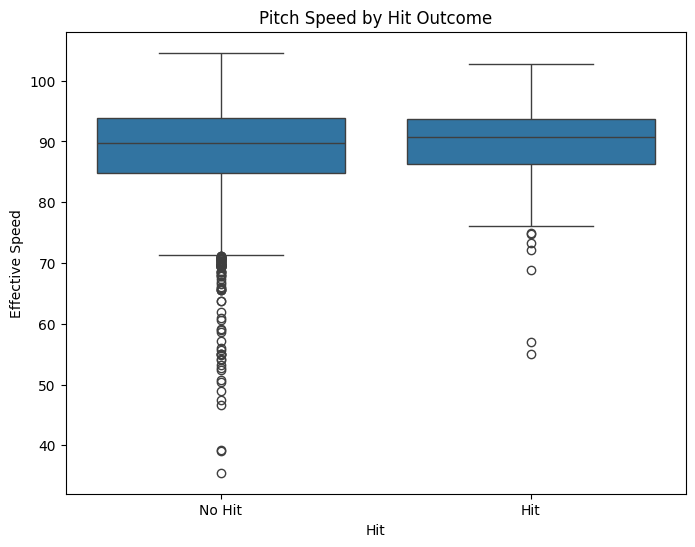

In [ ]:
sns.boxplot(data=data, x='hits', y='effective_speed')
plt.title('Pitch Speed by Hit Outcome')
plt.xlabel('Hit')
plt.ylabel('Effective Speed')
plt.xticks([0, 1], ['No Hit', 'Hit'])
plt.show()

This graph is very interesting as both the average speed and middle 50% for both hits and no hits seems to be almost equal. Overall, pitches that are hit have a smaller spread without many outliers. Pitches that do not result in hits, however, have a huge amount of outliers, with many slow pitches not resulting in pitches. This seems to confirm what we saw in the first graph with the slower pitch types having a smaller hit rate.

Overall, these graphs help us understand better how exactly the predictors we have chosen can aid in predicting the outcome of a batted-ball event. We are able to see that a slurve or sinker thrown down the middle of the strike zone at a speed greater than 75 mph has a higher probability of resulting in a hit. Likewise, a curveball thrown toward the outside of the strike zone on the far side of the plate at a slow speed will generally not result in a hit.